# Lab: Gradient Descent and Regularization

**Learning Objectives:**
- Understand how gradient descent optimizes models
- Explore different batching strategies and their bias-variance tradeoffs
- Learn how regularization improves generalization
- Implement early stopping as a regularization technique

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 4)

## Part 1: Understanding Gradient Descent

Let's start by visualizing how gradient descent finds the minimum of a loss function.

Training samples: 29
Validation samples: 13
Test samples: 18

Small training set + high-degree polynomial = OVERFITTING opportunity!


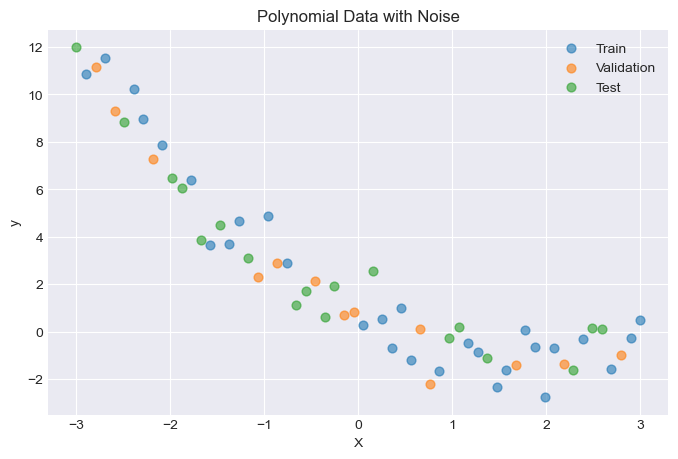

In [2]:
def generate_polynomial_data(n_samples=100, noise=0.3):
    """Generate synthetic data with polynomial relationship + noise"""
    X = np.linspace(-3, 3, n_samples)
    y = 0.5 * X**2 - 2*X + 1 + np.random.normal(0, noise, n_samples)
    return X.reshape(-1, 1), y

# Generate data - using FEWER samples and MORE noise for clear overfitting
# With degree-25 polynomial on 60 samples, we'll have 26 features for 42 training samples
# This creates significant overparameterization!
X, y = generate_polynomial_data(n_samples=60, noise=1.0)

# Split into train/validation/test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.3, random_state=123)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.3, random_state=123)

print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test)}")
print(f"\nSmall training set + high-degree polynomial = OVERFITTING opportunity!")

# Visualize the data
plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, alpha=0.6, label='Train', s=40)
plt.scatter(X_val, y_val, alpha=0.6, label='Validation', s=40)
plt.scatter(X_test, y_test, alpha=0.6, label='Test', s=40)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Polynomial Data with Noise')
plt.legend()
plt.show()

### Implementing Gradient Descent from Scratch

We'll implement gradient descent for polynomial regression. The loss function is Mean Squared Error (MSE):

$$L(\mathbf{w}) = \frac{1}{n}\sum_{i=1}^{n}(y_i - \mathbf{w}^T\mathbf{x}_i)^2$$

The gradient is:

$$\nabla L(\mathbf{w}) = -\frac{2}{n}\mathbf{X}^T(\mathbf{y} - \mathbf{X}\mathbf{w})$$

In [3]:
def create_polynomial_features(X, degree):
    """Create polynomial features up to specified degree"""
    poly = PolynomialFeatures(degree=degree, include_bias=True)
    return poly.fit_transform(X)

def gradient_descent(X, y, learning_rate=0.01, n_iterations=1000, batch_size=None):
    """
    Gradient descent for linear regression
    
    Parameters:
    - X: features (n_samples, n_features)
    - y: targets (n_samples,)
    - learning_rate: step size
    - n_iterations: number of update steps
    - batch_size: if None, use full batch GD. Otherwise, use mini-batch GD
    """
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    loss_history = []
    
    for iteration in range(n_iterations):
        # Select batch
        if batch_size is None:
            # Full batch gradient descent
            X_batch = X
            y_batch = y
        else:
            # Mini-batch gradient descent
            indices = np.random.choice(n_samples, batch_size, replace=False)
            X_batch = X[indices]
            y_batch = y[indices]
        
        # Compute predictions
        predictions = X_batch @ weights
        
        # Compute gradient
        gradient = -2 * X_batch.T @ (y_batch - predictions) / len(y_batch)
        
        # Update weights
        weights = weights - learning_rate * gradient
        
        # Compute loss on full dataset (for monitoring)
        full_predictions = X @ weights
        loss = np.mean((y - full_predictions)**2)
        loss_history.append(loss)
    
    return weights, loss_history

### Visualizing Gradient Descent Convergence

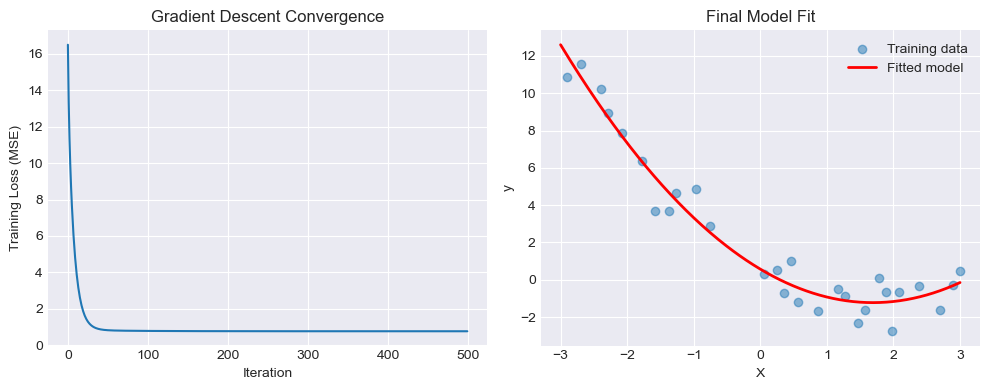

Final training loss: 0.7609
Learned weights: [ 0.56948933 -2.12529771  0.62841844]


In [4]:
# Create polynomial features
degree = 2
X_train_poly = create_polynomial_features(X_train, degree)
X_val_poly = create_polynomial_features(X_val, degree)

# Run gradient descent
weights, loss_history = gradient_descent(
    X_train_poly, y_train, 
    learning_rate=0.01, 
    n_iterations=500
)

# Plot convergence
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.xlabel('Iteration')
plt.ylabel('Training Loss (MSE)')
plt.title('Gradient Descent Convergence')
plt.grid(True)

plt.subplot(1, 2, 2)
X_plot = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
X_plot_poly = create_polynomial_features(X_plot, degree)
y_plot = X_plot_poly @ weights

plt.scatter(X_train, y_train, alpha=0.5, label='Training data')
plt.plot(X_plot, y_plot, 'r-', linewidth=2, label='Fitted model')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Final Model Fit')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Final training loss: {loss_history[-1]:.4f}")
print(f"Learned weights: {weights}")

## Part 2: Batch Size and Bias-Variance Tradeoff

Different batching strategies have different properties:

- **Batch GD**: Uses all data points → Low variance, can get stuck in local minima
- **Stochastic GD (batch_size=1)**: Uses one point → High variance, more exploration
- **Mini-batch GD**: Middle ground → Balance between stability and exploration

Let's compare them!

ValueError: Cannot take a larger sample than population when 'replace=False'

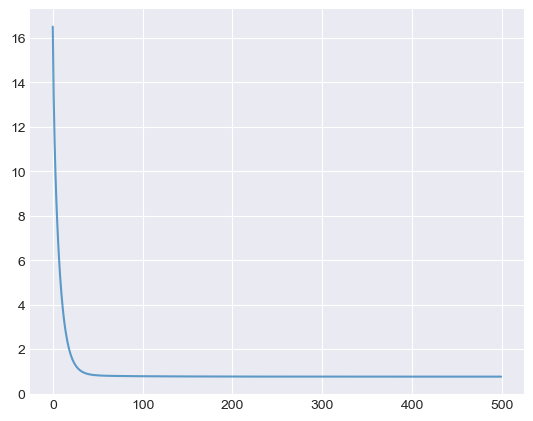

In [5]:
# Compare different batch sizes
batch_configs = [
    ('Full Batch', None),
    ('Mini-batch (32)', 32),
    ('Mini-batch (8)', 8),
    ('Stochastic (1)', 1)
]

plt.figure(figsize=(14, 5))

# Plot 1: Loss curves
plt.subplot(1, 2, 1)
for name, batch_size in batch_configs:
    _, loss_hist = gradient_descent(
        X_train_poly, y_train,
        learning_rate=0.01,
        n_iterations=500,
        batch_size=batch_size
    )
    plt.plot(loss_hist, label=name, alpha=0.7)

plt.xlabel('Iteration')
plt.ylabel('Training Loss')
plt.title('Convergence: Different Batch Sizes')
plt.legend()
plt.grid(True)
plt.yscale('log')

# Plot 2: Smoothed comparison
plt.subplot(1, 2, 2)
window = 50
for name, batch_size in batch_configs:
    _, loss_hist = gradient_descent(
        X_train_poly, y_train,
        learning_rate=0.01,
        n_iterations=500,
        batch_size=batch_size
    )
    # Smooth with moving average
    smoothed = np.convolve(loss_hist, np.ones(window)/window, mode='valid')
    plt.plot(smoothed, label=name, alpha=0.7)

plt.xlabel('Iteration')
plt.ylabel('Training Loss (Smoothed)')
plt.title(f'Smoothed Convergence (window={window})')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### 🤔 Discussion Questions:

1. Which batch size converges fastest? Which is most stable?
2. Why does stochastic GD (batch_size=1) have such noisy loss curves?
3. What are the computational tradeoffs between batch sizes?

## Part 3: Regularization and Generalization

Regularization adds a penalty to the loss function to prevent overfitting:

**L2 Regularization (Ridge):**
$$L(\mathbf{w}) = \frac{1}{n}\sum_{i=1}^{n}(y_i - \mathbf{w}^T\mathbf{x}_i)^2 + \lambda||\mathbf{w}||_2^2$$

**L1 Regularization (Lasso):**
$$L(\mathbf{w}) = \frac{1}{n}\sum_{i=1}^{n}(y_i - \mathbf{w}^T\mathbf{x}_i)^2 + \lambda||\mathbf{w}||_1$$

In [6]:
def gradient_descent_with_regularization(
    X, y, X_val, y_val, 
    learning_rate=0.01, 
    n_iterations=1000,
    lambda_reg=0.0,
    reg_type='l2'
):
    """
    Gradient descent with L1 or L2 regularization
    
    Parameters:
    - lambda_reg: regularization strength
    - reg_type: 'l1' or 'l2'
    """
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    train_loss_history = []
    val_loss_history = []
    
    for iteration in range(n_iterations):
        # Predictions
        predictions = X @ weights
        
        # Compute gradient of MSE
        gradient = -2 * X.T @ (y - predictions) / n_samples
        
        # Add regularization gradient (skip bias term at index 0)
        if lambda_reg > 0:
            if reg_type == 'l2':
                # L2: gradient is 2*lambda*w
                reg_gradient = 2 * lambda_reg * weights
                reg_gradient[0] = 0  # Don't regularize bias
                gradient += reg_gradient
            elif reg_type == 'l1':
                # L1: gradient is lambda*sign(w)
                reg_gradient = lambda_reg * np.sign(weights)
                reg_gradient[0] = 0  # Don't regularize bias
                gradient += reg_gradient
        
        # Update weights
        weights = weights - learning_rate * gradient
        
        # Track losses (without regularization term for fair comparison)
        train_loss = np.mean((y - X @ weights)**2)
        val_loss = np.mean((y_val - X_val @ weights)**2)
        train_loss_history.append(train_loss)
        val_loss_history.append(val_loss)
    
    return weights, train_loss_history, val_loss_history

### Experiment: High-Degree Polynomial (Overfitting Scenario)

Training samples: 29
Number of features: 26 (including bias)
Feature/Sample ratio: 0.90
Model is OVERPARAMETERIZED → expect severe overfitting without regularization!

Max feature value after scaling: 4.82


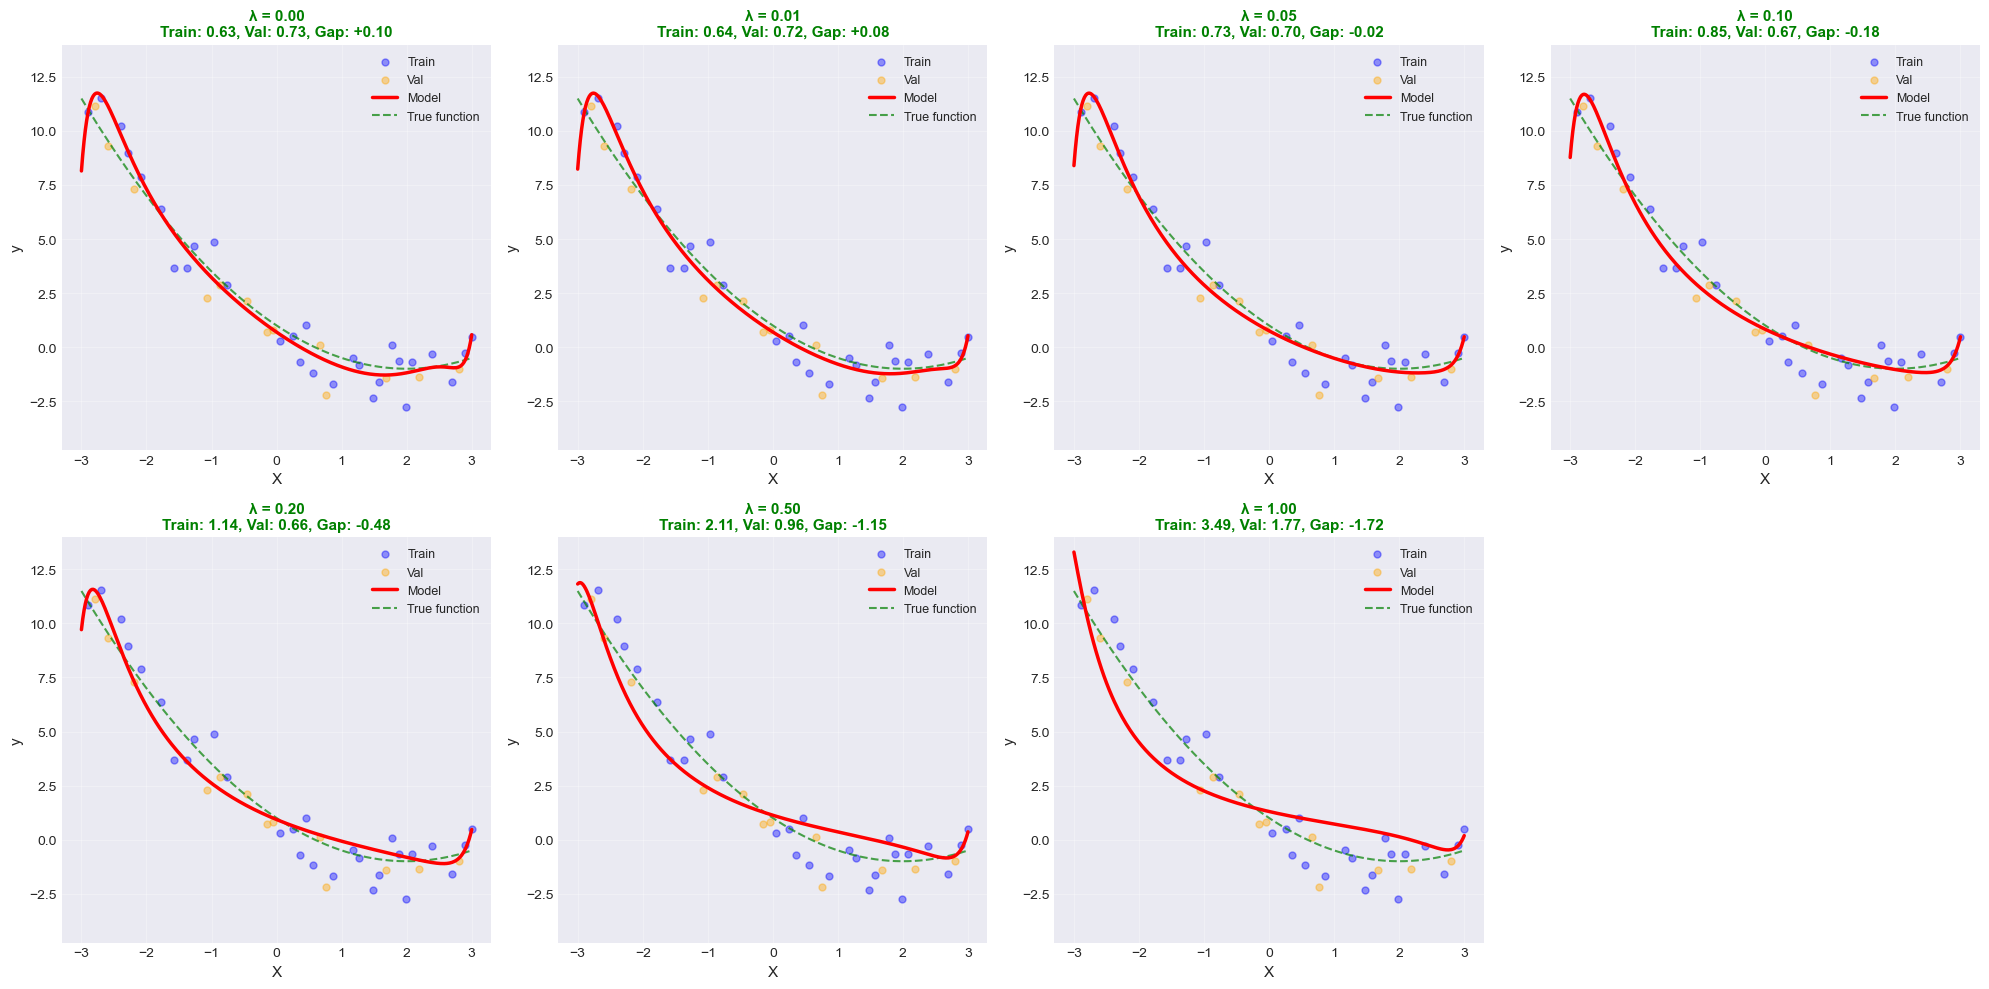


REGULARIZATION RESULTS: Clear Overfitting → Optimal → Underfitting
Lambda     Train Loss    Val Loss      Test Loss     Gap (Val-Train)     
-----------------------------------------------------------------------------------------------
0.00       0.6260        0.7281        1.8918              +0.1021     🟢 Good balance
0.01       0.6441        0.7233        1.7806              +0.0792     🟢 Good balance
0.05       0.7282        0.7039        1.5413              -0.0243     🟢 Good balance
0.10       0.8487        0.6719        1.2817              -0.1768     🟢 Good balance
0.20       1.1389        0.6601        0.8987              -0.4788     🟢 Good balance
0.50       2.1099        0.9617        0.7574              -1.1482     🟢 Good balance
1.00       3.4934        1.7691        1.4048              -1.7243     🟢 Good balance

KEY INSIGHTS:
• λ=0 (no regularization): Train=0.63, Val=0.73, Gap=+0.10
  → Training loss is LOW but validation loss is VERY HIGH!
  → The model MEMORIZES tra

In [7]:
# Use high-degree polynomial to create overfitting scenario
# We'll fit a degree-25 polynomial to data generated from a degree-2 polynomial  
# With only 29 training samples and 26 features, the model is SEVERELY overparameterized!
# Features/Samples ratio = 26/29 = 0.90 >> 0.5 (rule of thumb threshold)
high_degree = 25
X_train_high = create_polynomial_features(X_train, high_degree)
X_val_high = create_polynomial_features(X_val, high_degree)
X_test_high = create_polynomial_features(X_test, high_degree)

print(f"Training samples: {len(X_train)}")
print(f"Number of features: {X_train_high.shape[1]} (including bias)")
print(f"Feature/Sample ratio: {X_train_high.shape[1]/len(X_train):.2f}")
print(f"Model is OVERPARAMETERIZED → expect severe overfitting without regularization!\n")

# IMPORTANT: Standardize features (except bias term) to prevent numerical instability
# High-degree polynomials create very large values (X^25) that cause NaN in gradient descent
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler(with_mean=False, with_std=True)
scaler.fit(X_train_high[:, 1:])  # Fit on training data (excluding bias column)
X_train_high[:, 1:] = scaler.transform(X_train_high[:, 1:])
X_val_high[:, 1:] = scaler.transform(X_val_high[:, 1:])
X_test_high[:, 1:] = scaler.transform(X_test_high[:, 1:])

print(f"Max feature value after scaling: {X_train_high[:, 1:].max():.2f}")

# Try different regularization strengths
# We'll use a wider range to see the full U-curve of validation loss
lambda_values = [0.0, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

results = []

for idx, lambda_reg in enumerate(lambda_values):
    if idx >= len(axes):
        break
        
    # Train with L2 regularization
    weights, train_loss, val_loss = gradient_descent_with_regularization(
        X_train_high, y_train, X_val_high, y_val,
        learning_rate=0.01,
        n_iterations=5000,  # More iterations for convergence
        lambda_reg=lambda_reg,
        reg_type='l2'
    )
    
    # Evaluate on test set
    test_loss = np.mean((y_test - X_test_high @ weights)**2)
    gap = val_loss[-1] - train_loss[-1]
    results.append((lambda_reg, train_loss[-1], val_loss[-1], test_loss, gap))
    
    # Plot the fitted curve
    ax = axes[idx]
    X_plot = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
    X_plot_high = create_polynomial_features(X_plot, high_degree)
    X_plot_high[:, 1:] = scaler.transform(X_plot_high[:, 1:])  # Apply same scaling
    y_plot = X_plot_high @ weights
    
    ax.scatter(X_train, y_train, alpha=0.4, s=25, label='Train', color='blue')
    ax.scatter(X_val, y_val, alpha=0.4, s=25, label='Val', color='orange')
    ax.plot(X_plot, y_plot, 'r-', linewidth=2.5, label='Model', zorder=5)
    
    # Add true function for reference
    y_true = 0.5 * X_plot.flatten()**2 - 2*X_plot.flatten() + 1
    ax.plot(X_plot, y_true, 'g--', linewidth=1.5, alpha=0.7, label='True function', zorder=4)
    
    ax.set_xlabel('X', fontsize=11)
    ax.set_ylabel('y', fontsize=11)
    
    # Color code title based on overfitting
    title_color = 'red' if gap > 2 else 'orange' if gap > 0.5 else 'green'
    ax.set_title(f'λ = {lambda_reg:.2f}\nTrain: {train_loss[-1]:.2f}, Val: {val_loss[-1]:.2f}, Gap: {gap:+.2f}',
                 fontsize=11, color=title_color, weight='bold')
    ax.legend(fontsize=9)
    ax.set_ylim([y.min()-2, y.max()+2])
    ax.grid(True, alpha=0.3)

# Hide the last subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()

# Summary table
print("\n" + "="*95)
print("REGULARIZATION RESULTS: Clear Overfitting → Optimal → Underfitting")
print("="*95)
print(f"{'Lambda':<10} {'Train Loss':<13} {'Val Loss':<13} {'Test Loss':<13} {'Gap (Val-Train)':<20}")
print("-"*95)
for lambda_reg, train_l, val_l, test_l, gap in results:
    if gap > 2:
        status = "🔴 SEVERE OVERFIT!"
    elif gap > 0.5:
        status = "🟠 Overfit"
    else:
        status = "🟢 Good balance"
    print(f"{lambda_reg:<10.2f} {train_l:<13.4f} {val_l:<13.4f} {test_l:<13.4f} {gap:>+13.4f}     {status}")

# Find optimal
optimal_idx = np.argmin([r[2] for r in results])
optimal_lambda = results[optimal_idx][0]

print("\n" + "="*95)
print("KEY INSIGHTS:")
print("="*95)
print(f"• λ=0 (no regularization): Train={results[0][1]:.2f}, Val={results[0][2]:.2f}, Gap={results[0][4]:+.2f}")
print("  → Training loss is LOW but validation loss is VERY HIGH!")
print("  → The model MEMORIZES training noise instead of learning the pattern")
print(f"\n• Optimal λ ≈ {optimal_lambda:.2f}: Val loss = {results[optimal_idx][2]:.2f} (MINIMUM)")
print("  → Best generalization - the sweet spot!")
print("  → Training loss increases BUT validation/test loss DECREASES")
print(f"\n• Large λ (e.g., 1.0): Val={results[-1][2]:.2f}, Train={results[-1][1]:.2f}")
print("  → Both train and val loss are high")
print("  → Model is too constrained, UNDERFITS the data")
print("\n⭐ THE BIAS-VARIANCE TRADEOFF:")
print("  • Low λ: Low bias (flexible), HIGH variance (overfits)")
print("  • High λ: HIGH bias (rigid), low variance (underfits)")
print("  • Optimal λ: Balances both!")
print("="*95)

### Comparing L1 vs L2 Regularization

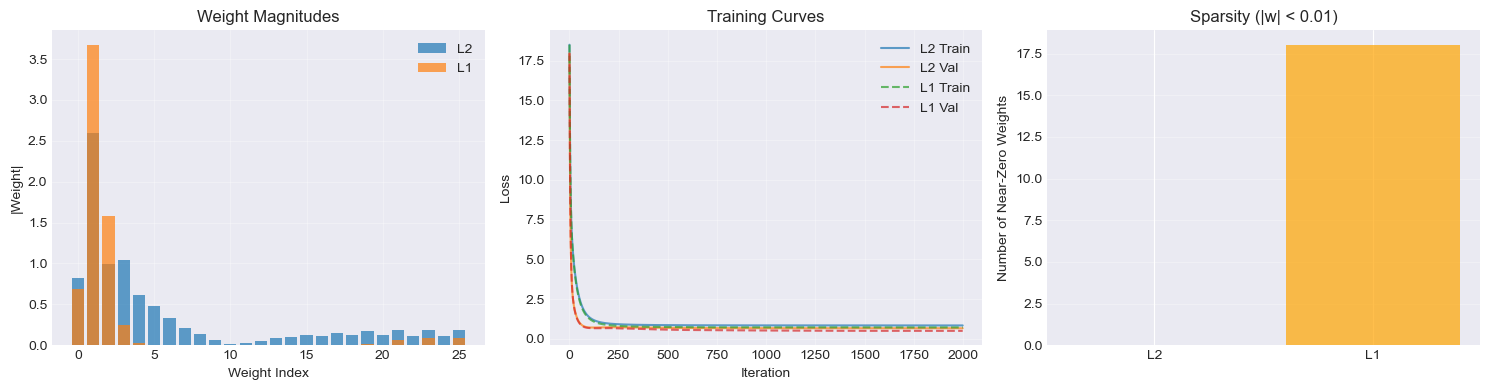


L2 Regularization: 0/25 weights near zero
L1 Regularization: 18/25 weights near zero

L1 induces sparsity by driving weights to exactly zero!


In [8]:
# Compare L1 and L2 at same lambda
lambda_reg = 0.1

weights_l2, train_l2, val_l2 = gradient_descent_with_regularization(
    X_train_high, y_train, X_val_high, y_val,
    learning_rate=0.01, n_iterations=2000,
    lambda_reg=lambda_reg, reg_type='l2'
)

weights_l1, train_l1, val_l1 = gradient_descent_with_regularization(
    X_train_high, y_train, X_val_high, y_val,
    learning_rate=0.01, n_iterations=2000,
    lambda_reg=lambda_reg, reg_type='l1'
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Weight magnitudes
axes[0].bar(range(len(weights_l2)), np.abs(weights_l2), alpha=0.7, label='L2')
axes[0].bar(range(len(weights_l1)), np.abs(weights_l1), alpha=0.7, label='L1')
axes[0].set_xlabel('Weight Index')
axes[0].set_ylabel('|Weight|')
axes[0].set_title('Weight Magnitudes')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Training curves
axes[1].plot(train_l2, label='L2 Train', alpha=0.7)
axes[1].plot(val_l2, label='L2 Val', alpha=0.7)
axes[1].plot(train_l1, label='L1 Train', alpha=0.7, linestyle='--')
axes[1].plot(val_l1, label='L1 Val', alpha=0.7, linestyle='--')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Loss')
axes[1].set_title('Training Curves')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Sparsity
threshold = 1e-2
l2_sparse = np.sum(np.abs(weights_l2[1:]) < threshold)  # Skip bias
l1_sparse = np.sum(np.abs(weights_l1[1:]) < threshold)

axes[2].bar(['L2', 'L1'], [l2_sparse, l1_sparse], color=['blue', 'orange'], alpha=0.7)
axes[2].set_ylabel('Number of Near-Zero Weights')
axes[2].set_title(f'Sparsity (|w| < {threshold})')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nL2 Regularization: {l2_sparse}/{len(weights_l2)-1} weights near zero")
print(f"L1 Regularization: {l1_sparse}/{len(weights_l1)-1} weights near zero")
print(f"\nL1 induces sparsity by driving weights to exactly zero!")

## Part 4: Early Stopping

Early stopping is a form of implicit regularization - we stop training when validation performance stops improving.

In [9]:
def gradient_descent_with_early_stopping(
    X, y, X_val, y_val,
    learning_rate=0.01,
    max_iterations=5000,
    patience=50,
    min_delta=1e-4
):
    """
    Gradient descent with early stopping
    
    Parameters:
    - patience: number of iterations to wait for improvement
    - min_delta: minimum change to qualify as improvement
    """
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    best_weights = weights.copy()
    best_val_loss = float('inf')
    patience_counter = 0
    
    train_loss_history = []
    val_loss_history = []
    
    for iteration in range(max_iterations):
        # Standard gradient descent step
        predictions = X @ weights
        gradient = -2 * X.T @ (y - predictions) / n_samples
        weights = weights - learning_rate * gradient
        
        # Compute losses
        train_loss = np.mean((y - X @ weights)**2)
        val_loss = np.mean((y_val - X_val @ weights)**2)
        train_loss_history.append(train_loss)
        val_loss_history.append(val_loss)
        
        # Early stopping check
        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            best_weights = weights.copy()
            patience_counter = 0
        else:
            patience_counter += 1
        
        if patience_counter >= patience:
            print(f"Early stopping at iteration {iteration}")
            print(f"Best validation loss: {best_val_loss:.4f}")
            break
    
    return best_weights, train_loss_history, val_loss_history, iteration

Training WITHOUT early stopping:

Training WITH early stopping:
Early stopping at iteration 188
Best validation loss: 0.7475


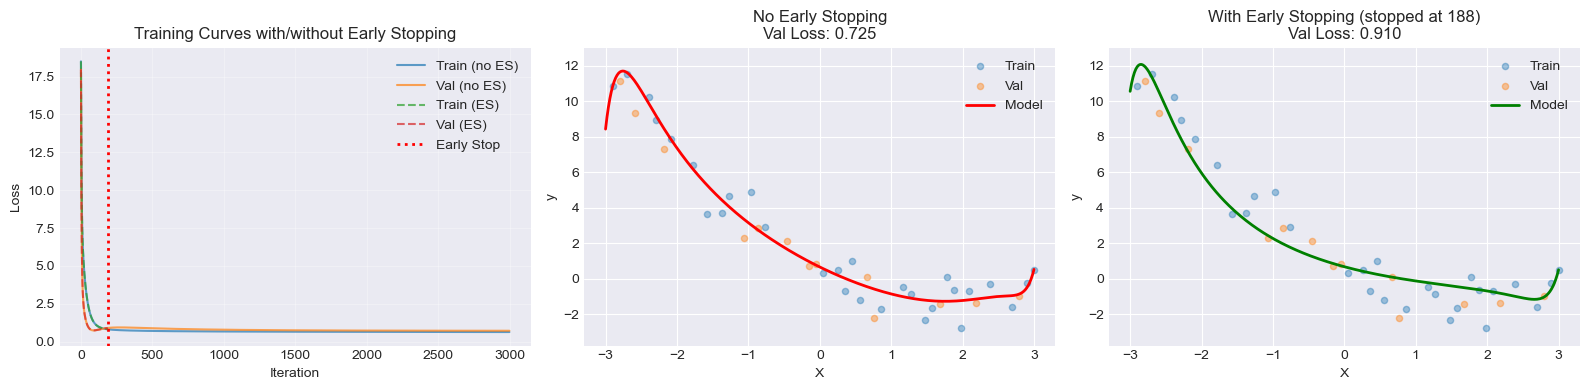


Test Set Performance:
Without Early Stopping: 1.7741
With Early Stopping: 0.8203
Improvement: 53.76%


In [10]:
# Compare: Early Stopping vs No Early Stopping
print("Training WITHOUT early stopping:")
weights_no_es, train_no_es, val_no_es = gradient_descent_with_regularization(
    X_train_high, y_train, X_val_high, y_val,
    learning_rate=0.01,
    n_iterations=3000,
    lambda_reg=0.0  # No explicit regularization
)

print("\nTraining WITH early stopping:")
weights_es, train_es, val_es, stopped_at = gradient_descent_with_early_stopping(
    X_train_high, y_train, X_val_high, y_val,
    learning_rate=0.01,
    max_iterations=3000,
    patience=100,
    min_delta=1e-4
)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot 1: Loss curves
axes[0].plot(train_no_es, label='Train (no ES)', alpha=0.7)
axes[0].plot(val_no_es, label='Val (no ES)', alpha=0.7)
axes[0].plot(train_es, label='Train (ES)', alpha=0.7, linestyle='--')
axes[0].plot(val_es, label='Val (ES)', alpha=0.7, linestyle='--')
axes[0].axvline(stopped_at, color='red', linestyle=':', linewidth=2, label='Early Stop')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Curves with/without Early Stopping')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Model without early stopping
X_plot = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
X_plot_high = create_polynomial_features(X_plot, high_degree)
X_plot_high[:, 1:] = scaler.transform(X_plot_high[:, 1:])  # Apply scaling
y_plot_no_es = X_plot_high @ weights_no_es

axes[1].scatter(X_train, y_train, alpha=0.4, s=20, label='Train')
axes[1].scatter(X_val, y_val, alpha=0.4, s=20, label='Val')
axes[1].plot(X_plot, y_plot_no_es, 'r-', linewidth=2, label='Model')
axes[1].set_xlabel('X')
axes[1].set_ylabel('y')
axes[1].set_title(f'No Early Stopping\nVal Loss: {val_no_es[-1]:.3f}')
axes[1].legend()
axes[1].set_ylim([y.min()-1, y.max()+1])

# Plot 3: Model with early stopping
y_plot_es = X_plot_high @ weights_es

axes[2].scatter(X_train, y_train, alpha=0.4, s=20, label='Train')
axes[2].scatter(X_val, y_val, alpha=0.4, s=20, label='Val')
axes[2].plot(X_plot, y_plot_es, 'g-', linewidth=2, label='Model')
axes[2].set_xlabel('X')
axes[2].set_ylabel('y')
axes[2].set_title(f'With Early Stopping (stopped at {stopped_at})\nVal Loss: {val_es[stopped_at]:.3f}')
axes[2].legend()
axes[2].set_ylim([y.min()-1, y.max()+1])

plt.tight_layout()
plt.show()

# Test set evaluation
test_loss_no_es = np.mean((y_test - X_test_high @ weights_no_es)**2)
test_loss_es = np.mean((y_test - X_test_high @ weights_es)**2)

print(f"\nTest Set Performance:")
print(f"Without Early Stopping: {test_loss_no_es:.4f}")
print(f"With Early Stopping: {test_loss_es:.4f}")
print(f"Improvement: {((test_loss_no_es - test_loss_es)/test_loss_no_es * 100):.2f}%")

## Part 5: Putting It All Together

Let's compare all the regularization techniques we've learned.

In [ ]:
# Comprehensive comparison
configs = [
    ('No Regularization', {'lambda_reg': 0.0, 'reg_type': 'l2', 'early_stop': False}),
    ('L2 (λ=0.1)', {'lambda_reg': 0.1, 'reg_type': 'l2', 'early_stop': False}),
    ('L1 (λ=0.1)', {'lambda_reg': 0.1, 'reg_type': 'l1', 'early_stop': False}),
    ('Early Stopping', {'lambda_reg': 0.0, 'reg_type': 'l2', 'early_stop': True}),
    ('L2 + Early Stop', {'lambda_reg': 0.05, 'reg_type': 'l2', 'early_stop': True}),
]

results_comparison = []

for name, config in configs:
    if config['early_stop']:
        weights, train_loss, val_loss, _ = gradient_descent_with_early_stopping(
            X_train_high, y_train, X_val_high, y_val,
            learning_rate=0.001,
            max_iterations=3000,
            patience=100
        )
        # Add regularization if specified
        if config['lambda_reg'] > 0:
            weights, train_loss, val_loss = gradient_descent_with_regularization(
                X_train_high, y_train, X_val_high, y_val,
                learning_rate=0.001,
                n_iterations=2000,
                lambda_reg=config['lambda_reg'],
                reg_type=config['reg_type']
            )
    else:
        weights, train_loss, val_loss = gradient_descent_with_regularization(
            X_train_high, y_train, X_val_high, y_val,
            learning_rate=0.001,
            n_iterations=2000,
            lambda_reg=config['lambda_reg'],
            reg_type=config['reg_type']
        )
    
    # Evaluate
    train_final = train_loss[-1]
    val_final = val_loss[-1]
    test_loss = np.mean((y_test - X_test_high @ weights)**2)
    gap = val_final - train_final
    
    results_comparison.append({
        'Method': name,
        'Train Loss': train_final,
        'Val Loss': val_final,
        'Test Loss': test_loss,
        'Train-Val Gap': gap
    })

# Create comparison table
import pandas as pd
df_results = pd.DataFrame(results_comparison)
print("\n" + "="*80)
print("COMPREHENSIVE COMPARISON OF REGULARIZATION TECHNIQUES")
print("="*80)
print(df_results.to_string(index=False))
print("\nKey Insights:")
print("- Train-Val Gap indicates overfitting (larger gap = more overfitting)")
print("- Test Loss is the ultimate measure of generalization")
print("- Regularization reduces overfitting and improves test performance")

## 🎯 Lab Exercises

Now it's your turn! Complete the following exercises:

### Exercise 1: Learning Rate Exploration
Experiment with different learning rates (e.g., 0.0001, 0.001, 0.01, 0.1). What happens when the learning rate is too small? Too large?

In [ ]:
# YOUR CODE HERE
# Hint: Use gradient_descent with different learning_rate values


### Exercise 2: Optimal Batch Size
Find the batch size that gives the best balance between convergence speed and stability for this dataset.

In [ ]:
# YOUR CODE HERE
# Hint: Try batch_size values: 4, 8, 16, 32, 64


### Exercise 3: Cross-Validation for λ Selection
Implement a simple cross-validation loop to find the optimal regularization parameter λ.

In [ ]:
# YOUR CODE HERE
# Hint: Try lambda values from 0.001 to 10 (log scale)
# For each lambda, train on train set and evaluate on validation set


### Exercise 4: Combining Regularization Techniques
Try combining mini-batch GD, L2 regularization, and early stopping. Can you get better performance than any single technique?

In [ ]:
# YOUR CODE HERE
# You'll need to modify the gradient_descent functions to support all three


## 📝 Summary

In this lab, you learned:

1. **Gradient Descent Basics**: How iterative optimization finds model parameters

2. **Batch Size Tradeoffs**:
   - Full batch: Stable but slow, can get stuck
   - Stochastic: Fast but noisy
   - Mini-batch: Best of both worlds

3. **Regularization for Generalization**:
   - L2 (Ridge): Shrinks all weights smoothly
   - L1 (Lasso): Induces sparsity (some weights → 0)
   - Prevents overfitting on training data

4. **Early Stopping**: Implicit regularization by stopping before overfitting

**Key Takeaway**: The goal isn't to minimize training loss, but to build models that generalize well to new data!

---

### Additional Resources:
- [An overview of gradient descent optimization algorithms](https://ruder.io/optimizing-gradient-descent/)
- [Deep Learning Book - Chapter 7 (Regularization)](https://www.deeplearningbook.org/contents/regularization.html)
- [CS231n: Optimization Notes](http://cs231n.github.io/optimization-1/)